# Clustering Methods and Evaluation

## Datasets and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

from sklearn.preprocessing import StandardScaler

# ══════════════════════════════════════════════════════════════════════════
# Wholesale Customers dataset
# ══════════════════════════════════════════════════════════════════════════
ws_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/00292/Wholesale%20customers%20data.csv"
)
df_ws = pd.read_csv(ws_url)
df_ws.columns = df_ws.columns.str.strip().str.lower().str.replace(" ", "_")

channel   = df_ws["channel"].copy()   # 1=Horeca, 2=Retail
region    = df_ws["region"].copy()    # 1=Lisbon, 2=Oporto, 3=Other
spend_cols = ["fresh","milk","grocery","frozen","detergents_paper","delicassen"]
X_ws = df_ws[spend_cols].copy()

print("=== Wholesale Customers ===")
print(f"  Observations : {X_ws.shape[0]}")
print(f"  Features     : {X_ws.shape[1]}  ({spend_cols})")
print(f"  Channel mix  : Horeca={(channel==1).sum()}  Retail={(channel==2).sum()}")
print(f"\n  Spending summary (monetary units):")
print(X_ws.describe().round(0).to_string())

# ── Log + Standard scaling ────────────────────────────────────────────────
X_ws_log    = np.log1p(X_ws.values)
scaler      = StandardScaler()
X_ws_scaled = scaler.fit_transform(X_ws_log)

=== Wholesale Customers ===
  Observations : 440
  Features     : 6  (['fresh', 'milk', 'grocery', 'frozen', 'detergents_paper', 'delicassen'])
  Channel mix  : Horeca=298  Retail=142

  Spending summary (monetary units):
          fresh     milk  grocery   frozen  detergents_paper  delicassen
count     440.0    440.0    440.0    440.0             440.0       440.0
mean    12000.0   5796.0   7951.0   3072.0            2881.0      1525.0
std     12647.0   7380.0   9503.0   4855.0            4768.0      2820.0
min         3.0     55.0      3.0     25.0               3.0         3.0
25%      3128.0   1533.0   2153.0    742.0             257.0       408.0
50%      8504.0   3627.0   4756.0   1526.0             816.0       966.0
75%     16934.0   7190.0  10656.0   3554.0            3922.0      1820.0
max    112151.0  73498.0  92780.0  60869.0           40827.0     47943.0


### Fitting $k$-Means

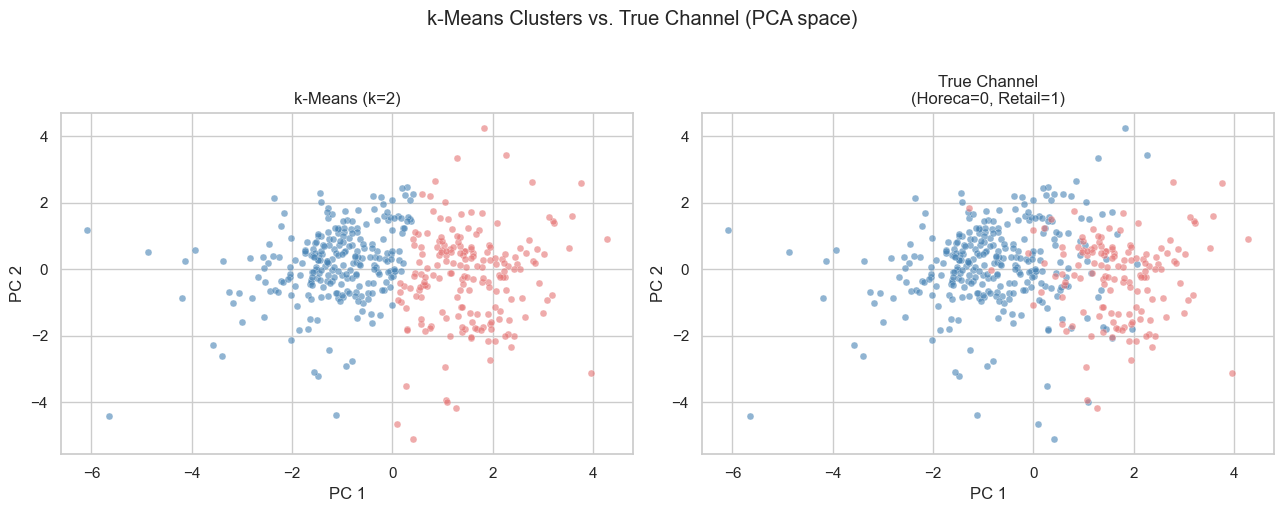

ARI vs. Channel label : 0.5135
k-means cluster    0    1
channel                  
Horeca           244   54
Retail             8  134


In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# ── k=2 first pass (Horeca vs Retail is the known binary structure) ────────
km2        = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_SEED)
labels_km2 = km2.fit_predict(X_ws_scaled)

# ── Project to 2D for visualisation (PCA used purely for plotting) ─────────
pca_vis  = PCA(n_components=2, random_state=RANDOM_SEED)
X_ws_2d  = pca_vis.fit_transform(X_ws_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ["steelblue", "#E57373"]

for ax, labels, title in [
    (axes[0], labels_km2,            "k-Means (k=2)"),
    (axes[1], channel.values - 1,    "True Channel\n(Horeca=0, Retail=1)"),
]:
    for cid, col in enumerate(palette):
        mask = labels == cid
        ax.scatter(X_ws_2d[mask, 0], X_ws_2d[mask, 1],
                   c=col, alpha=0.6, s=25, edgecolors="white", lw=0.3)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.set_title(title)

plt.suptitle("k-Means Clusters vs. True Channel (PCA space)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch5_kmeans_k2.png", dpi=150, bbox_inches="tight")
plt.show()

ari = adjusted_rand_score(channel.values - 1, labels_km2)
print(f"ARI vs. Channel label : {ari:.4f}")
print(pd.crosstab(channel.map({1:"Horeca",2:"Retail"}),
                  pd.Series(labels_km2, name="k-means cluster")))

### The Elbow Criterion

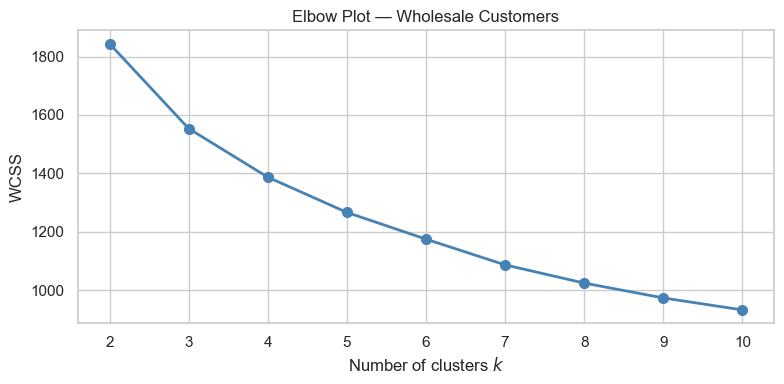

  k        WCSS    Delta WCSS   % reduction
--------------------------------------------
  2      1844.1           nan          nan%
  3      1553.4         290.7         15.8%
  4      1386.9         166.5         10.7%
  5      1266.1         120.7          8.7%
  6      1174.5          91.6          7.2%
  7      1086.4          88.2          7.5%
  8      1024.0          62.3          5.7%
  9       973.1          50.9          5.0%
 10       932.0          41.1          4.2%


In [3]:
k_range   = range(2, 11)
wcss_vals = []
km_models = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED)
    km.fit(X_ws_scaled)
    wcss_vals.append(km.inertia_)
    km_models.append(km)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), wcss_vals, "o-", color="steelblue", lw=2, ms=7)
plt.xlabel("Number of clusters $k$")
plt.ylabel("WCSS")
plt.title("Elbow Plot — Wholesale Customers")
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig(FIGURES / "ch5_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'k':>3}  {'WCSS':>10}  {'Delta WCSS':>12}  {'% reduction':>12}")
print("-" * 44)
for i, (k, w) in enumerate(zip(k_range, wcss_vals)):
    delta = wcss_vals[i-1] - w if i > 0 else float("nan")
    pct   = 100 * delta / wcss_vals[i-1] if i > 0 else float("nan")
    print(f"{k:>3}  {w:>10.1f}  {delta:>12.1f}  {pct:>11.1f}%")

## Hierarchical Clustering

### The Algorithm

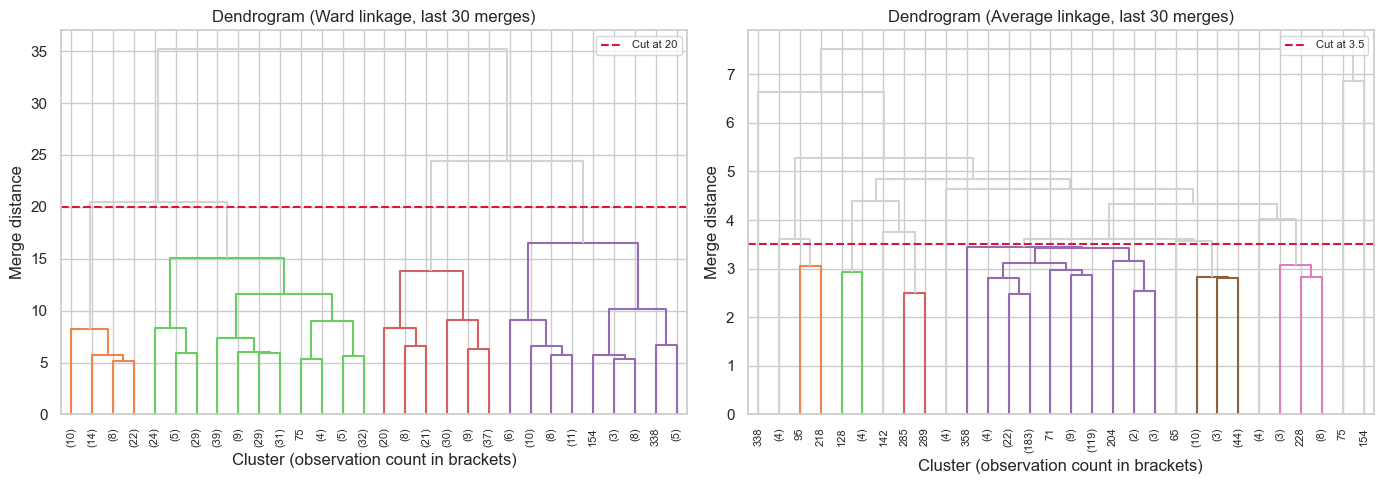

Ward (k=4) vs. k-means (k=4) ARI : 0.3977
Ward (k=4) vs. true channel ARI  : 0.3897


In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z_ward = linkage(X_ws_scaled, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, method, cut in [(axes[0], "ward", 20), (axes[1], "average", 3.5)]:
    Z = linkage(X_ws_scaled, method=method)
    dendrogram(Z, ax=ax, truncate_mode="lastp", p=30,
               color_threshold=cut, leaf_rotation=90,
               leaf_font_size=8, above_threshold_color="lightgray")
    ax.set_title(f"Dendrogram ({method.capitalize()} linkage, last 30 merges)")
    ax.set_xlabel("Cluster (observation count in brackets)")
    ax.set_ylabel("Merge distance")
    ax.axhline(cut, color="crimson", linestyle="--", lw=1.5,
               label=f"Cut at {cut}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "ch5_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

labels_ward4    = fcluster(Z_ward, t=4, criterion="maxclust") - 1
ari_vs_kmeans   = adjusted_rand_score(km_models[2].labels_, labels_ward4)
ari_vs_channel  = adjusted_rand_score(channel.values - 1, labels_ward4)
print(f"Ward (k=4) vs. k-means (k=4) ARI : {ari_vs_kmeans:.4f}")
print(f"Ward (k=4) vs. true channel ARI  : {ari_vs_channel:.4f}")

## Cluster Validation

### Internal Validation Metrics

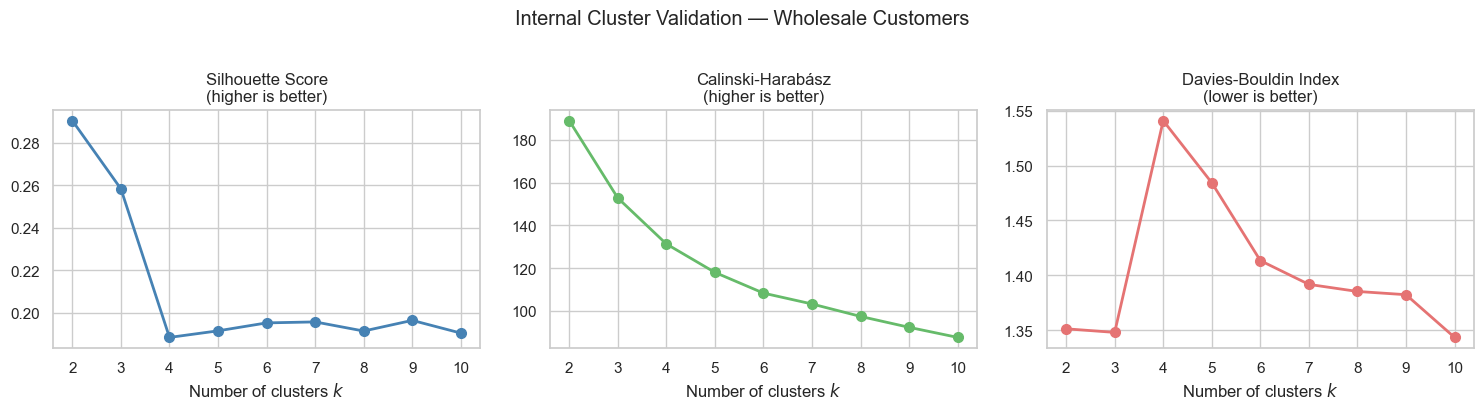

  k    Silhouette    CH Index    DB Index
------------------------------------------
  2        0.2903      189.05      1.3515
  3        0.2583      152.84      1.3482
  4        0.1885      131.32      1.5408
  5        0.1916      118.00      1.4843
  6        0.1953      108.30      1.4135
  7        0.1958      103.21      1.3919
  8        0.1915       97.39      1.3855
  9        0.1965       92.28      1.3825
 10        0.1905       87.56      1.3437


In [5]:
from sklearn.metrics import (silhouette_score,
                              calinski_harabasz_score,
                              davies_bouldin_score)

sil_scores, ch_scores, db_scores = [], [], []

for km in km_models:
    labels = km.labels_
    sil_scores.append(silhouette_score(X_ws_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_ws_scaled, labels))
    db_scores.append(davies_bouldin_score(X_ws_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [
    (sil_scores, "Silhouette Score",      "higher is better", "steelblue"),
    (ch_scores,  "Calinski-Harabász",     "higher is better", "#66BB6A"),
    (db_scores,  "Davies-Bouldin Index",  "lower is better",  "#E57373"),
]
for ax, (vals, title, note, color) in zip(axes, metrics):
    ax.plot(list(k_range), vals, "o-", color=color, lw=2, ms=7)
    ax.set_xlabel("Number of clusters $k$")
    ax.set_title(f"{title}\n({note})")
    ax.set_xticks(list(k_range))

plt.suptitle("Internal Cluster Validation — Wholesale Customers", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch5_validation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'k':>3}  {'Silhouette':>12}  {'CH Index':>10}  {'DB Index':>10}")
print("-" * 42)
for k, s, ch, db in zip(k_range, sil_scores, ch_scores, db_scores):
    print(f"{k:>3}  {s:>12.4f}  {ch:>10.2f}  {db:>10.4f}")

### Cluster Profiling

Cluster centroids (original monetary units):
             fresh    milk  grocery  frozen  detergents_paper  delicassen
Cluster 0    903.0  5915.0  10129.0   300.0            3425.0       247.0
Cluster 1  13987.0  3058.0   3644.0  3889.0             501.0      1452.0
Cluster 2   5860.0  1161.0   1603.0  1335.0             185.0       396.0
Cluster 3   7352.0  9179.0  13224.0  1330.0            4782.0      1590.0

Cluster sizes:
Cluster 0     61
Cluster 1    129
Cluster 2    132
Cluster 3    118


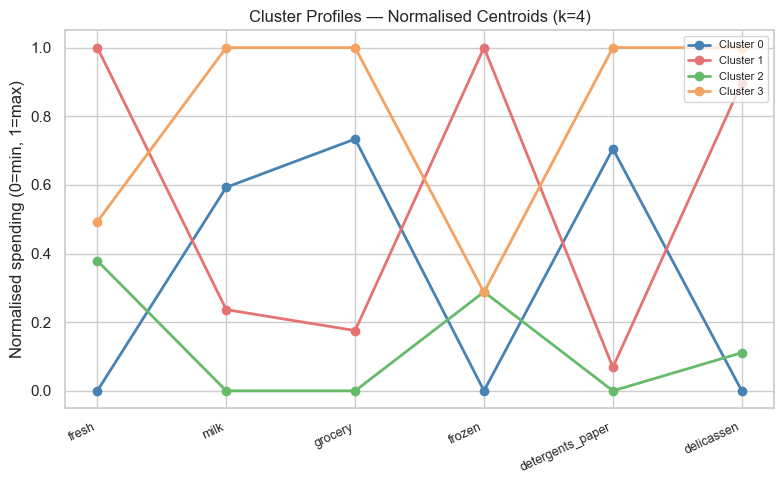

In [6]:
best_k    = 4
km_best   = km_models[best_k - 2]
labels_best = km_best.labels_

# Back-transform centroids to original monetary scale
centroids_log  = scaler.inverse_transform(km_best.cluster_centers_)
centroids_orig = np.expm1(centroids_log)
centroid_df    = pd.DataFrame(centroids_orig, columns=spend_cols,
                               index=[f"Cluster {c}" for c in range(best_k)])

print("Cluster centroids (original monetary units):")
print(centroid_df.round(0).to_string())
print(f"\nCluster sizes:")
print(pd.Series(labels_best).value_counts().sort_index()
      .rename(lambda i: f"Cluster {i}").to_string())

# Normalised centroid profile plot
fig, ax = plt.subplots(figsize=(8, 5))
colors  = ["steelblue","#E57373","#66BB6A","#F4A261"]
cent_norm = (centroid_df - centroid_df.min()) / (centroid_df.max() - centroid_df.min())

for i, (name, row) in enumerate(cent_norm.iterrows()):
    ax.plot(spend_cols, row.values, "o-", color=colors[i],
            lw=2, ms=6, label=name)

ax.set_title("Cluster Profiles — Normalised Centroids (k=4)")
ax.set_ylabel("Normalised spending (0=min, 1=max)")
ax.set_xticklabels(spend_cols, rotation=25, ha="right", fontsize=9)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES / "ch5_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()